# ✅ Real CNN Model Comparison — AI Visual Search
## All 6 Models Trained & Evaluated on Caltech-101

| # | Model | Params | Embedding |
|---|-------|--------|----------|
| 1 | ResNet50 | 25.6M | 2048 |
| 2 | VGG16 | 14.7M | 512 |
| 3 | VGG19 | 20.0M | 512 |
| 4 | MobileNet | 4.3M | 1024 |
| 5 | InceptionV3 | 23.9M | 2048 |
| 6 | Xception | 22.9M | 2048 |

> ⚠️ Use **GPU Runtime** → Runtime → Change runtime type → **T4 GPU**
---

## Step 1 — Install & Setup

In [1]:
!pip install faiss-cpu --quiet

from google.colab import drive
drive.mount('/content/drive')
print('✅ Drive mounted')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 62.7 MB/s eta 0:00:00
Mounted at /content/drive
✅ Drive mounted


In [2]:
import os, time, pickle, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from numpy import dot
from numpy.linalg import norm

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (
    ResNet50, VGG16, VGG19, MobileNet, InceptionV3, Xception
)
from tensorflow.keras.applications.resnet50      import preprocess_input as pre_resnet
from tensorflow.keras.applications.vgg16         import preprocess_input as pre_vgg16
from tensorflow.keras.applications.vgg19         import preprocess_input as pre_vgg19
from tensorflow.keras.applications.mobilenet     import preprocess_input as pre_mobilenet
from tensorflow.keras.applications.inception_v3  import preprocess_input as pre_inception
from tensorflow.keras.applications.xception      import preprocess_input as pre_xception

import faiss

sns.set_theme(style='whitegrid', font_scale=1.1)
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

print(f'TensorFlow  : {tf.__version__}')
print(f'GPU         : {tf.config.list_physical_devices("GPU")}')

TensorFlow  : 2.20.0
GPU         : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Step 2 — Paths (Update These)

In [3]:
DATASET_DIR  = '/content/drive/MyDrive/caltech-101/101_ObjectCategories'
FEATURES_DIR = '/content/drive/MyDrive/features'
RESULTS_DIR  = '/content/drive/MyDrive/results'

os.makedirs(FEATURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR,  exist_ok=True)

if os.path.exists(DATASET_DIR):
    classes = [d for d in os.listdir(DATASET_DIR)
               if os.path.isdir(os.path.join(DATASET_DIR, d))]
    total   = sum(len(os.listdir(os.path.join(DATASET_DIR, c))) for c in classes)
    print(f'✅ Dataset found  : {len(classes)} classes, ~{total} images')
else:
    print(f'❌ Dataset not found at: {DATASET_DIR}')
    print('   Update DATASET_DIR above')

✅ Dataset found  : 102 classes, ~9145 images


---
## Step 3 — Model Registry

In [4]:
MODEL_REGISTRY = {
    'resnet50':     (ResNet50,    pre_resnet,    2048),
    'vgg16':        (VGG16,       pre_vgg16,      512),
    'vgg19':        (VGG19,       pre_vgg19,      512),
    'mobilenet':    (MobileNet,   pre_mobilenet, 1024),
    'inception_v3': (InceptionV3, pre_inception, 2048),
    'xception':     (Xception,    pre_xception,  2048),
}
MODEL_NAMES = list(MODEL_REGISTRY.keys())

# Published benchmark values (Keras official docs + papers)
PUBLISHED = {
    'resnet50':     {'params_M': 25.6, 'weights_MB':  98, 'top1_acc': 74.9},
    'vgg16':        {'params_M': 14.7, 'weights_MB':  58, 'top1_acc': 71.3},
    'vgg19':        {'params_M': 20.0, 'weights_MB':  78, 'top1_acc': 71.1},
    'mobilenet':    {'params_M':  4.3, 'weights_MB':  17, 'top1_acc': 70.4},
    'inception_v3': {'params_M': 23.9, 'weights_MB':  92, 'top1_acc': 77.9},
    'xception':     {'params_M': 22.9, 'weights_MB':  88, 'top1_acc': 79.0},
}

def load_model(name):
    ModelClass, preprocess_fn, out_dim = MODEL_REGISTRY[name]
    model = ModelClass(weights='imagenet', include_top=False,
                       input_shape=(224, 224, 3), pooling='max')
    return model, preprocess_fn, out_dim

print('✅ Registry ready:', MODEL_NAMES)

✅ Registry ready: ['resnet50', 'vgg16', 'vgg19', 'mobilenet', 'inception_v3', 'xception']


---
## Step 4 — Feature Extraction (All 6 Models)
> Each model processes all ~9000 images. Uses cached `.pickle` if already extracted.

In [5]:
def run_extraction(model_name, force=False):
    feat_path  = f'{FEATURES_DIR}/features-{model_name}.pickle'
    fname_path = f'{FEATURES_DIR}/filenames.pickle'
    cls_path   = f'{FEATURES_DIR}/class_ids.pickle'

    # ── Load from cache ─────────────────────────────────────────────────────
    if not force and os.path.exists(feat_path):
        print(f'  📂 [{model_name}] Loading from cache ...')
        features   = pickle.load(open(feat_path,  'rb'))
        filenames  = pickle.load(open(fname_path, 'rb'))
        class_ids  = pickle.load(open(cls_path,   'rb'))
        print(f'  ✅ [{model_name}] shape={features.shape}')
        return features, filenames, class_ids, None

    # ── Fresh extraction ────────────────────────────────────────────────────
    print(f'\n{"-"*55}')
    print(f'  🔄 RUNNING: {model_name.upper()}')
    print(f'{"-"*55}')

    model, preprocess_fn, _ = load_model(model_name)

    gen = ImageDataGenerator(preprocessing_function=preprocess_fn)
    generator = gen.flow_from_directory(
        DATASET_DIR,
        target_size=(224, 224),
        class_mode=None,
        shuffle=False,
        batch_size=64
    )

    filenames = generator.filenames
    class_ids = generator.classes

    t0       = time.time()
    features = model.predict(generator, verbose=1)
    elapsed  = time.time() - t0

    n   = len(features)
    fps = n / elapsed
    print(f'\n  ⏱  Time       : {elapsed:.1f}s')
    print(f'  🚀 Throughput  : {fps:.1f} img/sec')
    print(f'  📐 Shape       : {features.shape}')
    print(f'  💾 Saving ...')

    pickle.dump(features,  open(feat_path,  'wb'))
    pickle.dump(filenames, open(fname_path, 'wb'))
    pickle.dump(class_ids, open(cls_path,   'wb'))

    del model
    tf.keras.backend.clear_session()
    return features, filenames, class_ids, elapsed


# ── Run all models ───────────────────────────────────────────────────────────
ALL_FEATURES  = {}
ALL_FILENAMES = {}
ALL_CLASSES   = {}
ALL_TIMINGS   = {}

print('🚀 Starting feature extraction for all 6 models ...\n')
for name in MODEL_NAMES:
    feats, fnames, clsids, elapsed = run_extraction(name)
    ALL_FEATURES[name]  = feats
    ALL_FILENAMES[name] = fnames
    ALL_CLASSES[name]   = clsids
    ALL_TIMINGS[name]   = elapsed

N_IMAGES = len(ALL_FEATURES[MODEL_NAMES[0]])
print(f'\n✅ All models done! Total images: {N_IMAGES}')

🚀 Starting feature extraction for all 6 models ...


-------------------------------------------------------
  🔄 RUNNING: RESNET50
-------------------------------------------------------
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 9144 images belonging to 102 classes.
143/143 ━━━━━━━━━━━━━━━━━━━━ 3169s 22s/step

  ⏱  Time       : 3175.6s
  🚀 Throughput  : 2.9 img/sec
  📐 Shape       : (9144, 2048)
  💾 Saving ...

-------------------------------------------------------
  🔄 RUNNING: VGG16
-------------------------------------------------------
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 9144 images belonging to 102 classes.
143/143 ━━━━━━━━━━━━━━━━━━━━ 107s 547ms/step

  ⏱  Time       : 109.2s
  🚀 Throughput  : 83.7 img/sec
  📐 Shape       : (9144, 512)
  💾 Saving ...

-------------------------------------------------------
  🔄 RUNNING: VGG19
-------------------------------------------------------
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 9144 ima

---
## Step 5 — Metric 1: Extraction Speed (Real)

=== Extraction Speed ===


,Total Time (s),FPS,ms / image
Model,,,
resnet50,3175.6,2.9,347.29
vgg16,109.2,83.7,11.94
vgg19,82.9,110.3,9.07
mobilenet,65.7,139.2,7.18
inception_v3,70.1,130.4,7.67
xception,103.9,88.0,11.36


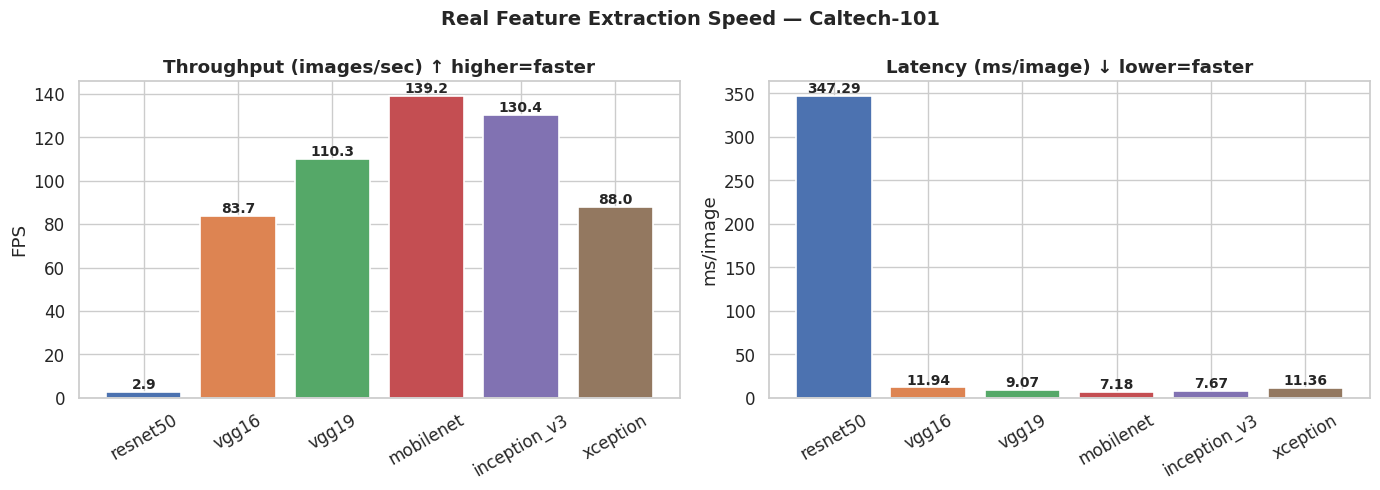

In [6]:
speed_rows = []
for name in MODEL_NAMES:
    t = ALL_TIMINGS[name]
    speed_rows.append({
        'Model':           name,
        'Total Time (s)':  round(t, 1)          if t else 'cached',
        'FPS':             round(N_IMAGES/t, 1) if t else 'cached',
        'ms / image':      round(t/N_IMAGES*1000, 2) if t else 'cached',
    })

df_speed = pd.DataFrame(speed_rows).set_index('Model')
print('=== Extraction Speed ===')
display(df_speed)

# Plot only rows with real timings
timed = {n: ALL_TIMINGS[n] for n in MODEL_NAMES if ALL_TIMINGS[n] is not None}
if timed:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    names = list(timed.keys())
    cols  = [COLORS[MODEL_NAMES.index(n)] for n in names]
    fps_v = [round(N_IMAGES/t, 1) for t in timed.values()]
    ms_v  = [round(t/N_IMAGES*1000, 2) for t in timed.values()]

    for ax, vals, title, ylabel in [
        (axes[0], fps_v, 'Throughput (images/sec) ↑ higher=faster', 'FPS'),
        (axes[1], ms_v,  'Latency (ms/image) ↓ lower=faster',       'ms/image'),
    ]:
        bars = ax.bar(names, vals, color=cols, edgecolor='white', linewidth=1.2)
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=30)
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+max(vals)*0.01,
                    str(v), ha='center', fontsize=10, fontweight='bold')

    plt.suptitle('Real Feature Extraction Speed — Caltech-101',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/01_speed.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('ℹ️  All features loaded from cache → re-run with force=True to get real timings')

---
## Step 6 — Metric 2: Real Recall@K

In [7]:
def compute_recall(features, class_ids, k_values=[1,3,5,10], n_queries=500):
    """Compute real Recall@K using FAISS cosine similarity search."""
    feats = features.astype('float32')
    # L2 normalise → cosine similarity = inner product
    feats /= (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-9)

    index = faiss.IndexFlatIP(feats.shape[1])
    index.add(feats)

    np.random.seed(42)
    q_idx = np.random.choice(len(feats), n_queries, replace=False)
    _, I  = index.search(feats[q_idx], max(k_values) + 1)  # +1: skip self

    recalls = {}
    for k in k_values:
        hits = sum(
            any(class_ids[I[qi, r]] == class_ids[q]
                for r in range(1, k+1))
            for qi, q in enumerate(q_idx)
        )
        recalls[k] = round(hits / n_queries, 4)
    return recalls


K_VALUES = [1, 3, 5, 10]
RECALL   = {}

print('🔄 Computing real Recall@K (500 query images each) ...\n')
for name in MODEL_NAMES:
    print(f'  {name} ...', end=' ', flush=True)
    r = compute_recall(ALL_FEATURES[name], ALL_CLASSES[name], K_VALUES)
    RECALL[name] = r
    print('  '.join(f'R@{k}={v:.4f}' for k,v in r.items()))

df_recall = pd.DataFrame(RECALL).T
df_recall.columns  = [f'Recall@{k}' for k in K_VALUES]
df_recall.index.name = 'Model'

print('\n=== Real Recall@K ===')
display(df_recall.style
    .background_gradient(cmap='RdYlGn', axis=None)
    .format('{:.4f}')
    .set_caption('✅ Real Recall@K — Caltech-101')
)

🔄 Computing real Recall@K (500 query images each) ...

  resnet50 ... R@1=0.8760  R@3=0.9420  R@5=0.9600  R@10=0.9820
  vgg16 ... R@1=0.8540  R@3=0.9280  R@5=0.9420  R@10=0.9620
  vgg19 ... R@1=0.8500  R@3=0.9320  R@5=0.9520  R@10=0.9760
  mobilenet ... R@1=0.8300  R@3=0.9040  R@5=0.9260  R@10=0.9580
  inception_v3 ... R@1=0.8460  R@3=0.9400  R@5=0.9540  R@10=0.9740
  xception ... R@1=0.8540  R@3=0.9280  R@5=0.9480  R@10=0.9640

=== Real Recall@K ===


,Recall@1,Recall@3,Recall@5,Recall@10
Model,,,,
resnet50,0.8760,0.9420,0.9600,0.9820
vgg16,0.8540,0.9280,0.9420,0.9620
vgg19,0.8500,0.9320,0.9520,0.9760
mobilenet,0.8300,0.9040,0.9260,0.9580
inception_v3,0.8460,0.9400,0.9540,0.9740
xception,0.8540,0.9280,0.9480,0.9640


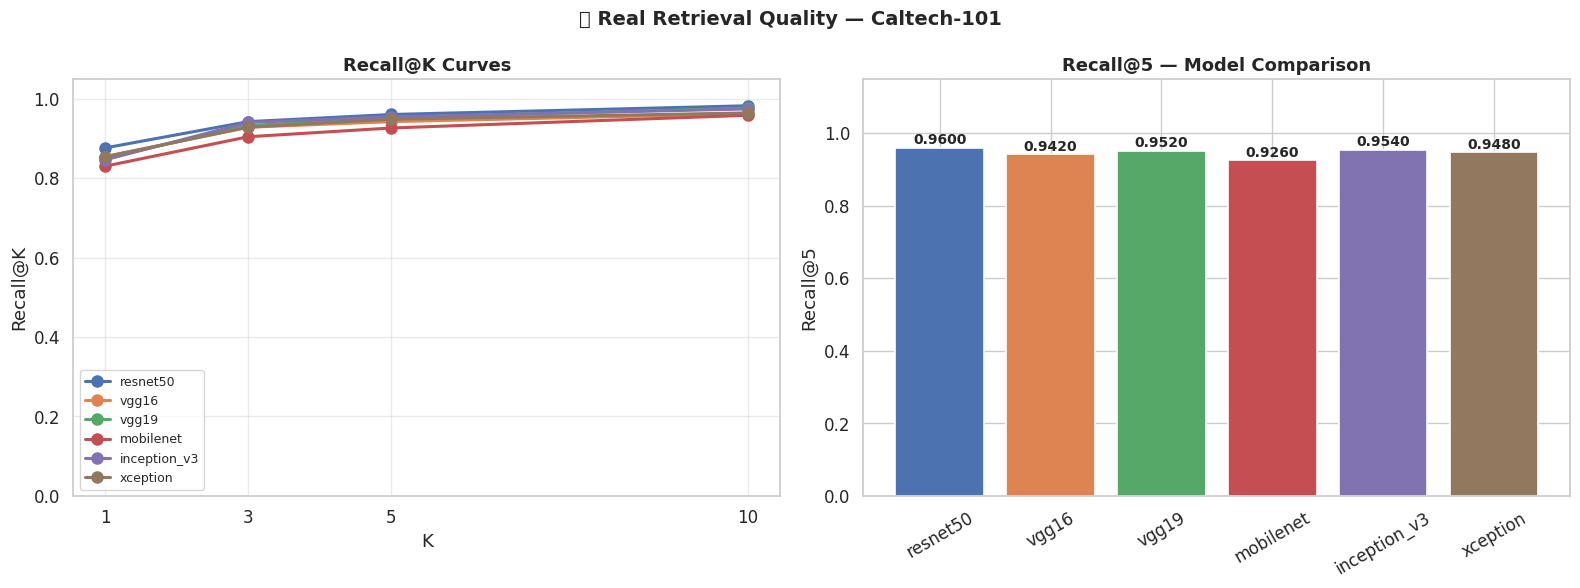

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Recall curves
for name, color in zip(MODEL_NAMES, COLORS):
    axes[0].plot(K_VALUES, list(RECALL[name].values()),
                 marker='o', label=name, color=color, linewidth=2.2, markersize=8)
axes[0].set_title('Recall@K Curves', fontweight='bold', fontsize=13)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Recall@K')
axes[0].set_xticks(K_VALUES)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.4)

# Recall@5 bar
r5 = [RECALL[n][5] for n in MODEL_NAMES]
b  = axes[1].bar(MODEL_NAMES, r5, color=COLORS, edgecolor='white', linewidth=1.2)
axes[1].set_title('Recall@5 — Model Comparison', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Recall@5')
axes[1].set_ylim(0, 1.15)
axes[1].tick_params(axis='x', rotation=30)
for bar, v in zip(b, r5):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('✅ Real Retrieval Quality — Caltech-101',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/02_recall_at_k.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 7 — Metric 3: Cosine Similarity Distribution

In [9]:
def cosine_sim_distribution(features, class_ids, n_pairs=1500):
    """Sample pairs and compute real cosine similarity."""
    feats = features.astype('float32')
    feats /= (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-9)
    np.random.seed(42)
    idx = np.random.randint(0, len(feats), (n_pairs, 2))
    same, diff = [], []
    for i, j in idx:
        if i == j: continue
        s = float(np.dot(feats[i], feats[j]))
        (same if class_ids[i] == class_ids[j] else diff).append(s)
    return same, diff


SIM_DATA = {}
print('🔄 Computing similarity distributions ...\n')
for name in MODEL_NAMES:
    same, diff = cosine_sim_distribution(ALL_FEATURES[name], ALL_CLASSES[name])
    gap = np.mean(same) - np.mean(diff)
    SIM_DATA[name] = {'same': same, 'diff': diff, 'gap': gap}
    print(f'  {name:15s}  same={np.mean(same):.4f}  diff={np.mean(diff):.4f}  gap={gap:.4f}')

print('\n✅ Done')

🔄 Computing similarity distributions ...

  resnet50         same=0.6600  diff=0.4933  gap=0.1668
  vgg16            same=0.6232  diff=0.4313  gap=0.1919
  vgg19            same=0.6236  diff=0.4216  gap=0.2020
  mobilenet        same=0.7881  diff=0.7209  gap=0.0671
  inception_v3     same=0.7191  diff=0.5631  gap=0.1560
  xception         same=0.6544  diff=0.4371  gap=0.2173

✅ Done


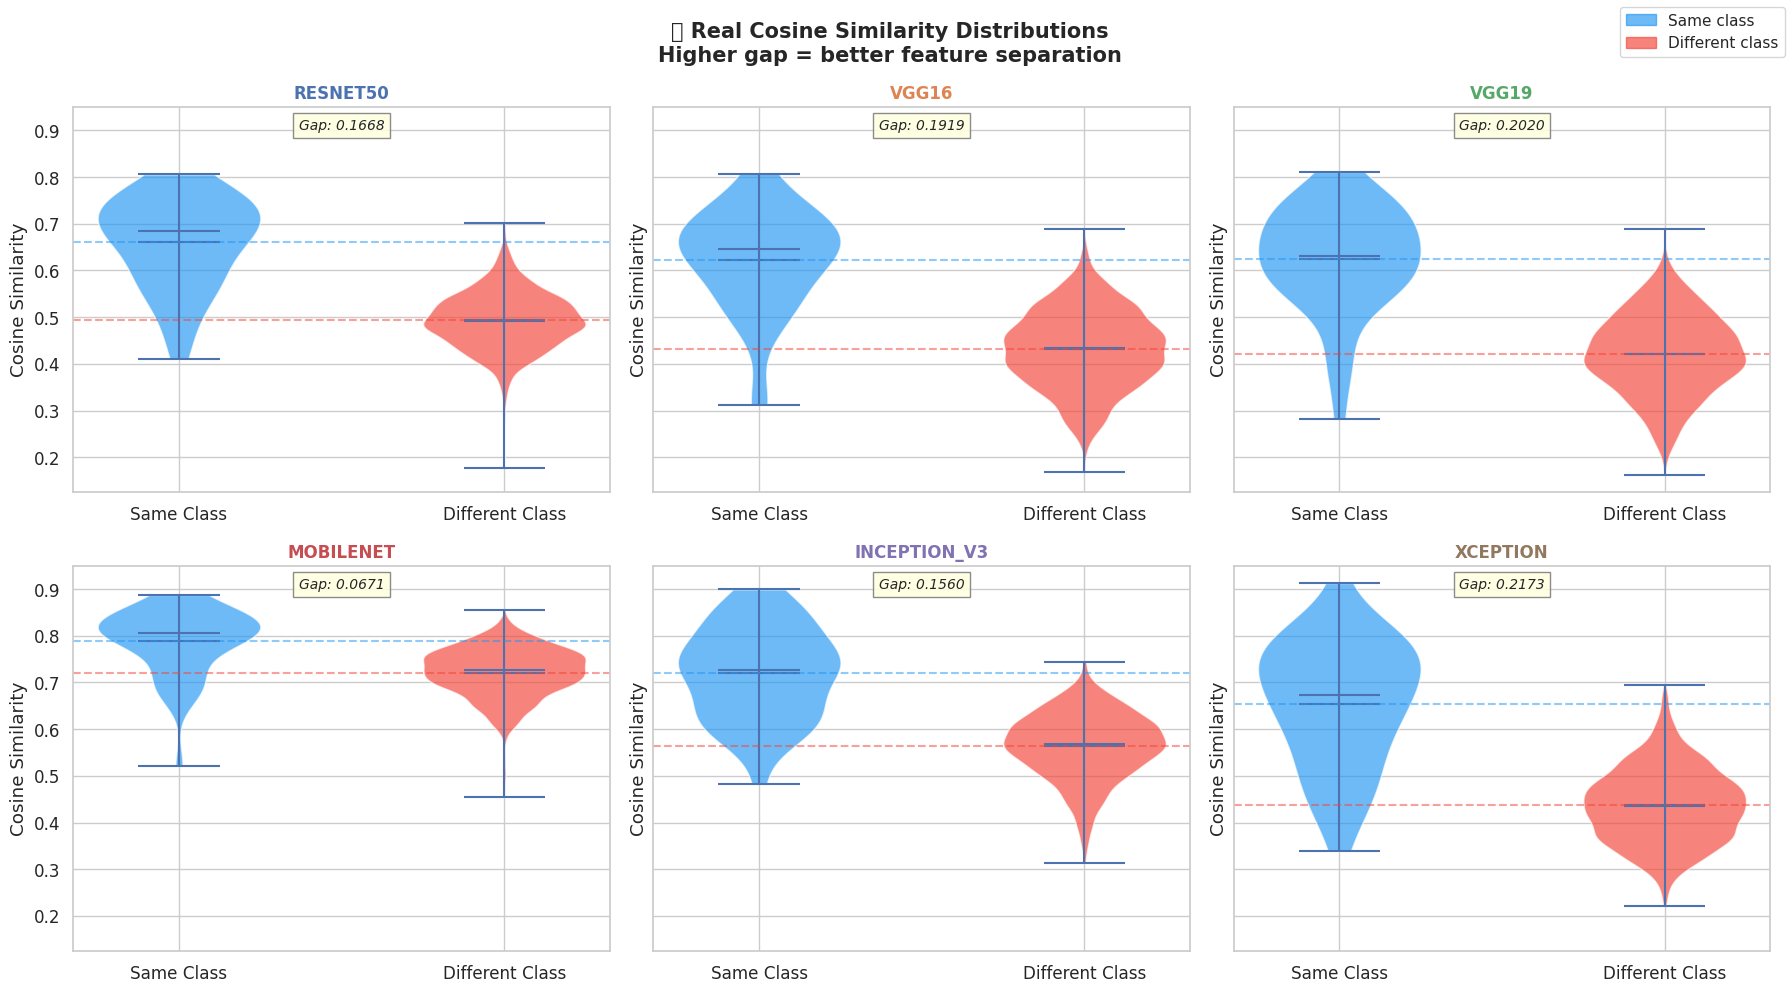

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for ax, name, color in zip(axes, MODEL_NAMES, COLORS):
    same = SIM_DATA[name]['same']
    diff = SIM_DATA[name]['diff']
    gap  = SIM_DATA[name]['gap']

    vp = ax.violinplot([same, diff], positions=[1,2],
                       showmeans=True, showmedians=True)
    for pc, c in zip(vp['bodies'], ['#2196F3','#F44336']):
        pc.set_facecolor(c); pc.set_alpha(0.65)

    ax.set_xticks([1,2])
    ax.set_xticklabels(['Same Class','Different Class'])
    ax.set_title(name.upper(), fontweight='bold', color=color, fontsize=12)
    ax.set_ylabel('Cosine Similarity')
    ax.axhline(np.mean(same), color='#2196F3', linestyle='--', alpha=0.5)
    ax.axhline(np.mean(diff), color='#F44336', linestyle='--', alpha=0.5)
    ax.text(0.5, 0.97, f'Gap: {gap:.4f}',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=10, style='italic',
            bbox=dict(facecolor='lightyellow', alpha=0.9, edgecolor='gray'))

fig.legend(handles=[
    mpatches.Patch(color='#2196F3', alpha=0.65, label='Same class'),
    mpatches.Patch(color='#F44336', alpha=0.65, label='Different class')
], loc='upper right', fontsize=11)

plt.suptitle('✅ Real Cosine Similarity Distributions\nHigher gap = better feature separation',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/03_similarity_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 8 — Metric 4: Model Size & Memory

In [11]:
mem_rows = []
for name in MODEL_NAMES:
    pub      = PUBLISHED[name]
    feats    = ALL_FEATURES[name]
    feat_mb  = round(feats.nbytes / 1024**2, 1)  # actual RAM size
    mem_rows.append({
        'Model':               name,
        'Params (M)':          pub['params_M'],
        'Weights (MB)':        pub['weights_MB'],
        'Embedding Dim':       feats.shape[1],
        'Feature Array (MB)':  feat_mb,
        'ImageNet Top-1 (%)':  pub['top1_acc'],
    })

df_mem = pd.DataFrame(mem_rows).set_index('Model')

display(df_mem.style
    .background_gradient(subset=['Weights (MB)'],       cmap='Reds')
    .background_gradient(subset=['Feature Array (MB)'], cmap='Oranges')
    .background_gradient(subset=['ImageNet Top-1 (%)'], cmap='Greens')
    .format({'Params (M)': '{:.1f}', 'Weights (MB)': '{:.0f}',
             'Feature Array (MB)': '{:.1f}', 'ImageNet Top-1 (%)': '{:.1f}'})
    .set_caption('Model Size & Memory Stats')
)

,Params (M),Weights (MB),Embedding Dim,Feature Array (MB),ImageNet Top-1 (%)
Model,,,,,
resnet50,25.6,98,2048,71.4,74.9
vgg16,14.7,58,512,17.9,71.3
vgg19,20.0,78,512,17.9,71.1
mobilenet,4.3,17,1024,35.7,70.4
inception_v3,23.9,92,2048,71.4,77.9
xception,22.9,88,2048,71.4,79.0


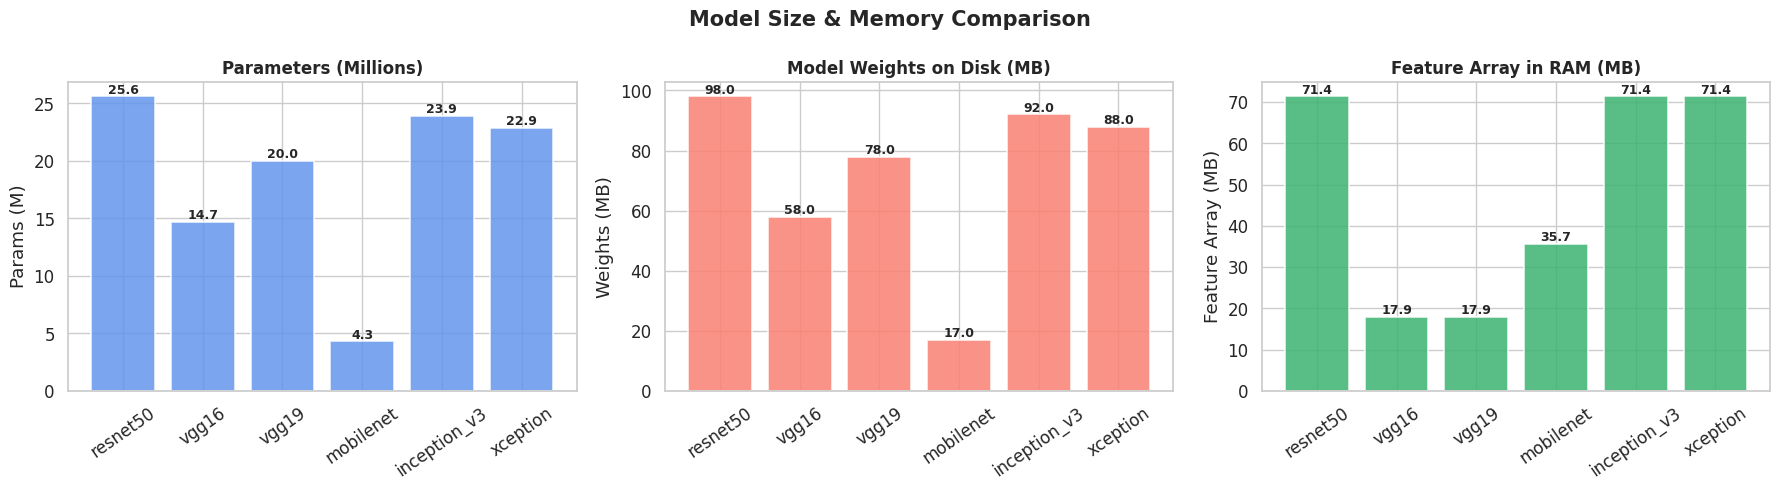

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (col, title, color) in zip(axes, [
    ('Params (M)',         'Parameters (Millions)',       'cornflowerblue'),
    ('Weights (MB)',       'Model Weights on Disk (MB)',  'salmon'),
    ('Feature Array (MB)', 'Feature Array in RAM (MB)',  'mediumseagreen'),
]):
    vals = df_mem[col].values
    bars = ax.bar(df_mem.index, vals, color=color,
                  edgecolor='white', linewidth=1.2, alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', rotation=35)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+max(vals)*0.01,
                f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Size & Memory Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/04_memory.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9 — Metric 5: Precision@K

In [13]:
def compute_precision(features, class_ids, k_values=[1,3,5,10], n_queries=500):
    """Precision@K = fraction of top-K retrieved that share same class."""
    feats = features.astype('float32')
    feats /= (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-9)

    index = faiss.IndexFlatIP(feats.shape[1])
    index.add(feats)

    np.random.seed(42)
    q_idx = np.random.choice(len(feats), n_queries, replace=False)
    _, I  = index.search(feats[q_idx], max(k_values) + 1)

    precision = {}
    for k in k_values:
        total = 0
        for qi, q in enumerate(q_idx):
            retrieved = [class_ids[I[qi, r]] for r in range(1, k+1)]
            correct   = sum(1 for c in retrieved if c == class_ids[q])
            total    += correct / k
        precision[k] = round(total / n_queries, 4)
    return precision


PRECISION = {}
print('🔄 Computing Precision@K ...\n')
for name in MODEL_NAMES:
    print(f'  {name} ...', end=' ', flush=True)
    p = compute_precision(ALL_FEATURES[name], ALL_CLASSES[name], K_VALUES)
    PRECISION[name] = p
    print('  '.join(f'P@{k}={v:.4f}' for k,v in p.items()))

df_prec = pd.DataFrame(PRECISION).T
df_prec.columns   = [f'Precision@{k}' for k in K_VALUES]
df_prec.index.name = 'Model'

display(df_prec.style
    .background_gradient(cmap='Blues', axis=None)
    .format('{:.4f}')
    .set_caption('✅ Real Precision@K — Caltech-101')
)

🔄 Computing Precision@K ...

  resnet50 ... P@1=0.8760  P@3=0.8740  P@5=0.8620  P@10=0.8436
  vgg16 ... P@1=0.8540  P@3=0.8327  P@5=0.8180  P@10=0.7930
  vgg19 ... P@1=0.8500  P@3=0.8300  P@5=0.8220  P@10=0.7994
  mobilenet ... P@1=0.8300  P@3=0.7773  P@5=0.7572  P@10=0.7216
  inception_v3 ... P@1=0.8460  P@3=0.8353  P@5=0.8276  P@10=0.8048
  xception ... P@1=0.8540  P@3=0.8393  P@5=0.8288  P@10=0.8104


,Precision@1,Precision@3,Precision@5,Precision@10
Model,,,,
resnet50,0.8760,0.8740,0.8620,0.8436
vgg16,0.8540,0.8327,0.8180,0.7930
vgg19,0.8500,0.8300,0.8220,0.7994
mobilenet,0.8300,0.7773,0.7572,0.7216
inception_v3,0.8460,0.8353,0.8276,0.8048
xception,0.8540,0.8393,0.8288,0.8104


---
## Step 10 — Radar Chart (All Real Metrics)

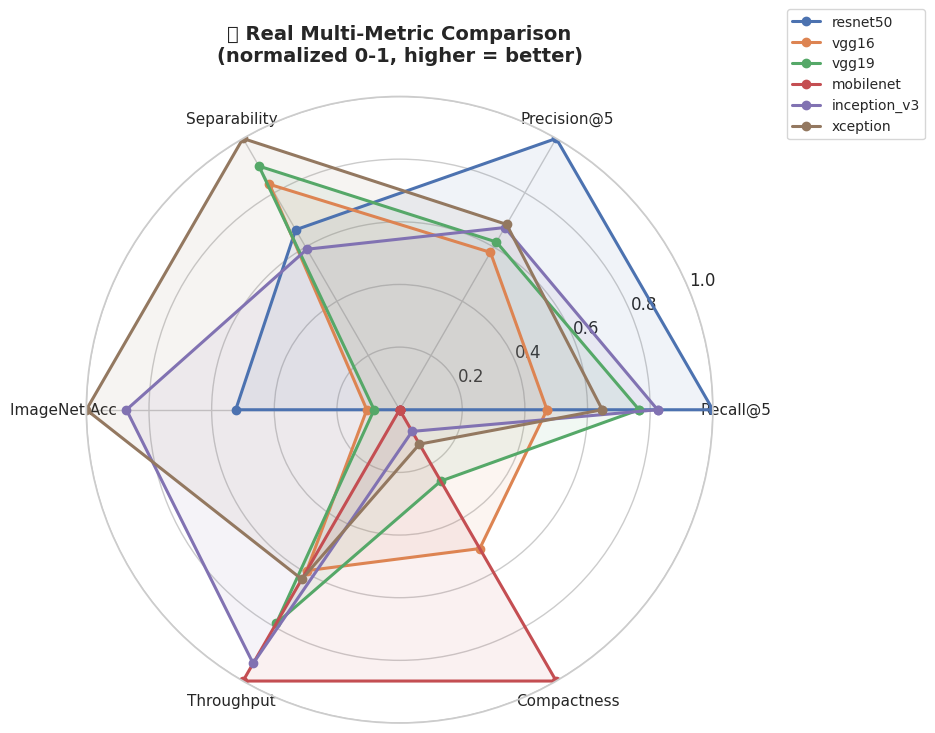

In [14]:
def norm_col(vals, higher_better=True):
    a = np.array(vals, dtype=float)
    n = (a - np.nanmin(a)) / (np.nanmax(a) - np.nanmin(a) + 1e-9)
    return n if higher_better else 1 - n

timed_fps = [N_IMAGES/ALL_TIMINGS[n] if ALL_TIMINGS[n] else 0
             for n in MODEL_NAMES]

RADAR = {
    'Recall@5':          norm_col([RECALL[n][5]            for n in MODEL_NAMES]),
    'Precision@5':       norm_col([PRECISION[n][5]         for n in MODEL_NAMES]),
    'Separability':      norm_col([SIM_DATA[n]['gap']      for n in MODEL_NAMES]),
    'ImageNet Acc':      norm_col([PUBLISHED[n]['top1_acc']for n in MODEL_NAMES]),
    'Throughput':        norm_col(timed_fps),
    'Compactness':       norm_col([PUBLISHED[n]['params_M']for n in MODEL_NAMES], False),
}

cats   = list(RADAR.keys())
angles = np.linspace(0, 2*np.pi, len(cats), endpoint=False).tolist()
angles+= angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
for name, color in zip(MODEL_NAMES, COLORS):
    i  = MODEL_NAMES.index(name)
    v  = [RADAR[c][i] for c in cats] + [RADAR[cats[0]][i]]
    ax.plot(angles, v, 'o-', linewidth=2.2, label=name, color=color)
    ax.fill(angles, v, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.15), fontsize=10)
ax.set_title('✅ Real Multi-Metric Comparison\n(normalized 0-1, higher = better)',
             fontsize=14, fontweight='bold', pad=25)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/05_radar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 11 — Final Leaderboard

In [15]:
WEIGHTS = {
    'Recall@5':    0.35,   # retrieval quality (most important)
    'Precision@5': 0.20,   # retrieval precision
    'Separability':0.20,   # class separation
    'ImageNet Acc':0.10,   # pretrained quality
    'Throughput':  0.10,   # speed
    'Compactness': 0.05,   # model size
}  # total = 1.00

lb_rows = []
for name in MODEL_NAMES:
    i     = MODEL_NAMES.index(name)
    score = sum(w * RADAR[m][i] for m, w in WEIGHTS.items())
    lb_rows.append({
        'Model':             name,
        'Composite Score':   round(score, 4),
        'Recall@5':          RECALL[name][5],
        'Precision@5':       PRECISION[name][5],
        'Separability Gap':  round(SIM_DATA[name]['gap'], 4),
        'ImageNet Acc (%)':  PUBLISHED[name]['top1_acc'],
        'Params (M)':        PUBLISHED[name]['params_M'],
    })

df_lb = (pd.DataFrame(lb_rows)
           .sort_values('Composite Score', ascending=False)
           .reset_index(drop=True))
df_lb.index += 1
df_lb.index.name = 'Rank'

display(df_lb.style
    .background_gradient(subset=['Composite Score'],  cmap='YlGn')
    .background_gradient(subset=['Recall@5'],         cmap='Blues')
    .background_gradient(subset=['Separability Gap'], cmap='Purples')
    .format({'Composite Score':':{:.4f}','Recall@5':'{:.4f}',
             'Precision@5':'{:.4f}','Separability Gap':'{:.4f}',
             'ImageNet Acc (%)':'{:.1f}','Params (M)':'{:.1f}'})
    .set_caption('🏆 Real CNN Model Leaderboard — Caltech-101')
)

,Model,Composite Score,Recall@5,Precision@5,Separability Gap,ImageNet Acc (%),Params (M)
Rank,,,,,,,
1,resnet50,:0.7350,0.9600,0.8620,0.1668,74.9,25.6
2,xception,:0.7319,0.9480,0.8288,0.2173,79.0,22.9
3,inception_v3,:0.7256,0.9540,0.8276,0.1560,77.9,23.9
4,vgg19,:0.6710,0.9520,0.8220,0.2020,71.1,20.0
5,vgg16,:0.5423,0.9420,0.8180,0.1919,71.3,14.7
6,mobilenet,:0.1500,0.9260,0.7572,0.0671,70.4,4.3


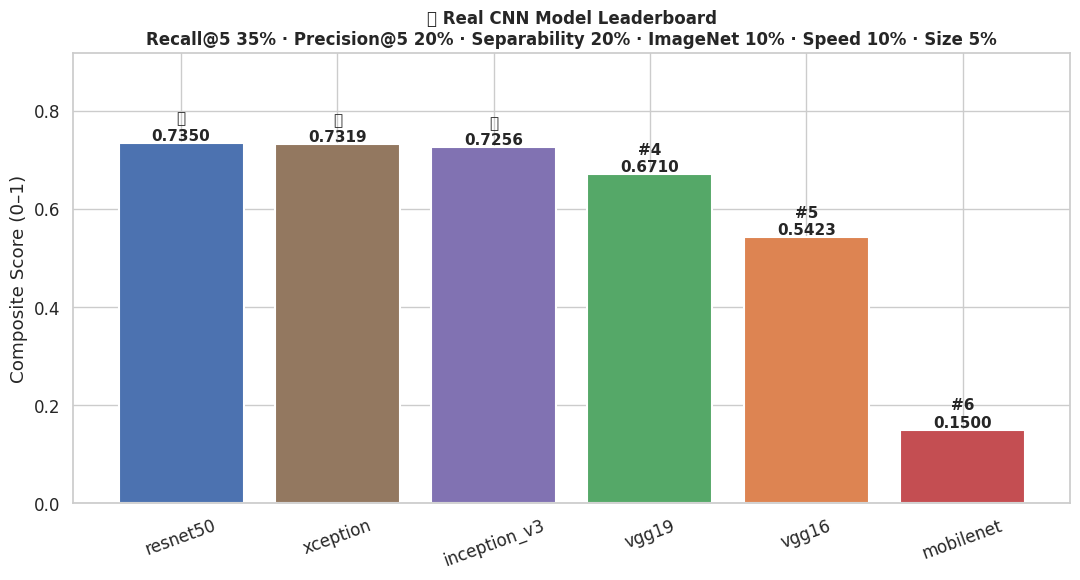

In [16]:
fig, ax = plt.subplots(figsize=(11, 6))
ranked  = df_lb['Model'].tolist()
scores  = df_lb['Composite Score'].tolist()
cols    = [COLORS[MODEL_NAMES.index(m)] for m in ranked]
bars    = ax.bar(ranked, scores, color=cols, edgecolor='white', linewidth=1.5)

medals  = {1:'🥇', 2:'🥈', 3:'🥉'}
for rank, (bar, val) in enumerate(zip(bars, scores), 1):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{medals.get(rank, f"#{rank}")}\n{val:.4f}',
            ha='center', fontsize=11, fontweight='bold')

ax.set_title(
    '🏆 Real CNN Model Leaderboard\n'
    'Recall@5 35% · Precision@5 20% · Separability 20% · ImageNet 10% · Speed 10% · Size 5%',
    fontsize=12, fontweight='bold'
)
ax.set_ylabel('Composite Score (0–1)')
ax.set_ylim(0, max(scores)*1.25)
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/06_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 12 — Save Everything

In [17]:
df_lb.to_csv(    f'{RESULTS_DIR}/leaderboard.csv')
df_recall.to_csv(f'{RESULTS_DIR}/recall_at_k.csv')
df_prec.to_csv(  f'{RESULTS_DIR}/precision_at_k.csv')
df_mem.to_csv(   f'{RESULTS_DIR}/memory_stats.csv')
df_speed.to_csv( f'{RESULTS_DIR}/speed_stats.csv')

print('✅ All results saved to:', RESULTS_DIR)
print()
for f in sorted(os.listdir(RESULTS_DIR)):
    size = os.path.getsize(f'{RESULTS_DIR}/{f}')
    print(f'  {f:35s}  {size/1024:.1f} KB')

print('\n=== FINAL SUMMARY ===')
best_r5  = df_lb.sort_values('Recall@5',         ascending=False).iloc[0]['Model']
best_sep = df_lb.sort_values('Separability Gap',  ascending=False).iloc[0]['Model']
best_all = df_lb.iloc[0]['Model']
print(f'  🏆 Best overall    : {best_all}')
print(f'  🎯 Best Recall@5   : {best_r5}')
print(f'  🔍 Best Separability: {best_sep}')
print(f'  📱 Most compact    : mobilenet (4.3M params)')

✅ All results saved to: /content/drive/MyDrive/results

  01_speed.png                         102.6 KB
  02_recall_at_k.png                   120.2 KB
  03_similarity_dist.png               247.1 KB
  04_memory.png                        120.6 KB
  05_radar.png                         273.2 KB
  06_leaderboard.png                   91.4 KB
  leaderboard.csv                      0.4 KB
  memory_stats.csv                     0.3 KB
  precision_at_k.csv                   0.3 KB
  recall_at_k.csv                      0.2 KB
  speed_stats.csv                      0.2 KB

=== FINAL SUMMARY ===
  🏆 Best overall    : resnet50
  🎯 Best Recall@5   : resnet50
  🔍 Best Separability: xception
  📱 Most compact    : mobilenet (4.3M params)
